# 02 — Unmixing pipeline

Noise estimation → HySime subspace dimension → MVSA endmember extraction →
SUNSAL abundance estimation, with diagnostics. This is the notebook version of
`scripts/run_pipeline.py` (which is what the Streamlit app consumes).
Replaces `analysis_elections_2025`.

In [22]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy, wasserstein_distance
from src.config import load_config

sns.set_style('whitegrid')
config = load_config()

In [3]:
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config
from src.unmixing import est_noise, hysime, mvsa, sunsal_mod

rng = np.random.seed(config['unmixing'].getint('seed'))

df = load_complete(config)
pre = preprocess_from_config(df, config)
Y_raw = pre.Y_raw
Y = pre.Y
L, N = Y.shape

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)


## Noise estimation + HySime

HySime signal subspace dimension kf = 7


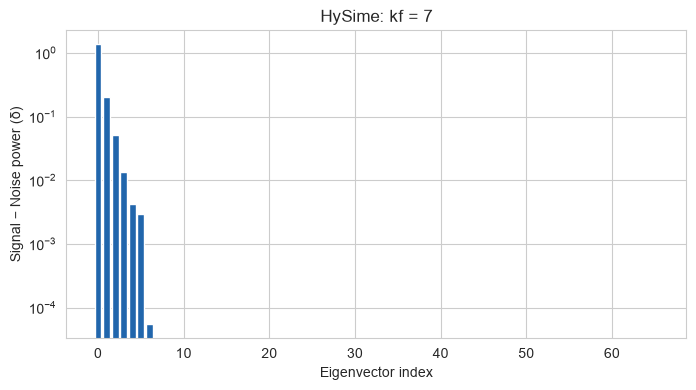

In [4]:
w_hat, Rw_hat = est_noise(Y, noise_type='additive', verbose=False)
kf, Ek, E, delta_p = hysime(Y, w_hat, Rw_hat, verbose=False)
print(f'HySime signal subspace dimension kf = {kf}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(delta_p)), delta_p,
       color=['#2166ac' if d > 0 else '#d1e5f0' for d in delta_p])
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Eigenvector index')
ax.set_ylabel('Signal − Noise power (δ)')
ax.set_yscale('log')
ax.set_title(f'HySime: kf = {kf}');

## MVSA endmember extraction

In [5]:
n_archetypes = config['unmixing'].getint('n_archetypes') or kf
print(f'n_archetypes = {n_archetypes}')

endm, Sest, Up, my, sing_values = mvsa(
    Y, p=n_archetypes,
    MM_iters=config['unmixing'].getint('mvsa_mm_iters'),
    spherize='yes', verbose=1)
endm.shape

n_archetypes = 6
SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


  iter 1: f0 = 15.7978, f = 12.0066
  iter 2: f0 = 12.0066, f = 11.6933
  iter 3: f0 = 11.6933, f = 11.3960
  iter 4: f0 = 11.3960, f = 11.0078
  iter 5: f0 = 11.0078, f = 10.8969
  iter 6: f0 = 10.8969, f = 10.5385
  iter 7: f0 = 10.5385, f = 10.5133
  iter 7: termination test PASSED


(66, 6)

## SUNSAL abundance estimation (positivity + sum-to-one)

In [6]:
abundances, res_p, res_d = sunsal_mod(
    endm, Y, positivity='yes', addone='yes',
    AL_iters=config['unmixing'].getint('sunsal_al_iters'),
    lambda_=0.0, tol=config['unmixing'].getfloat('sunsal_tol'), verbose='no')

neg_frac = np.mean(abundances < -1e-6)
sum_dev = np.abs(abundances.sum(axis=0) - 1.0)
print(f'abundances: {abundances.shape}')
print(f'fraction negative: {neg_frac:.6f}')
print(f'|sum-1| mean {sum_dev.mean():.2e}, max {sum_dev.max():.2e}')

abundances: (6, 92487)
fraction negative: 0.000000
|sum-1| mean 7.99e-08, max 3.43e-03


## Reconstruction quality

In [7]:
Y_rec = endm @ abundances
rss = np.sum((Y - Y_rec) ** 2)
rmse = np.sqrt(np.mean((Y - Y_rec) ** 2))
print(f'RSS:  {rss:.4f}')
print(f'RMSE: {rmse:.6f}')

RSS:  6930.4749
RMSE: 0.033695


### Candidate reconstruction plots

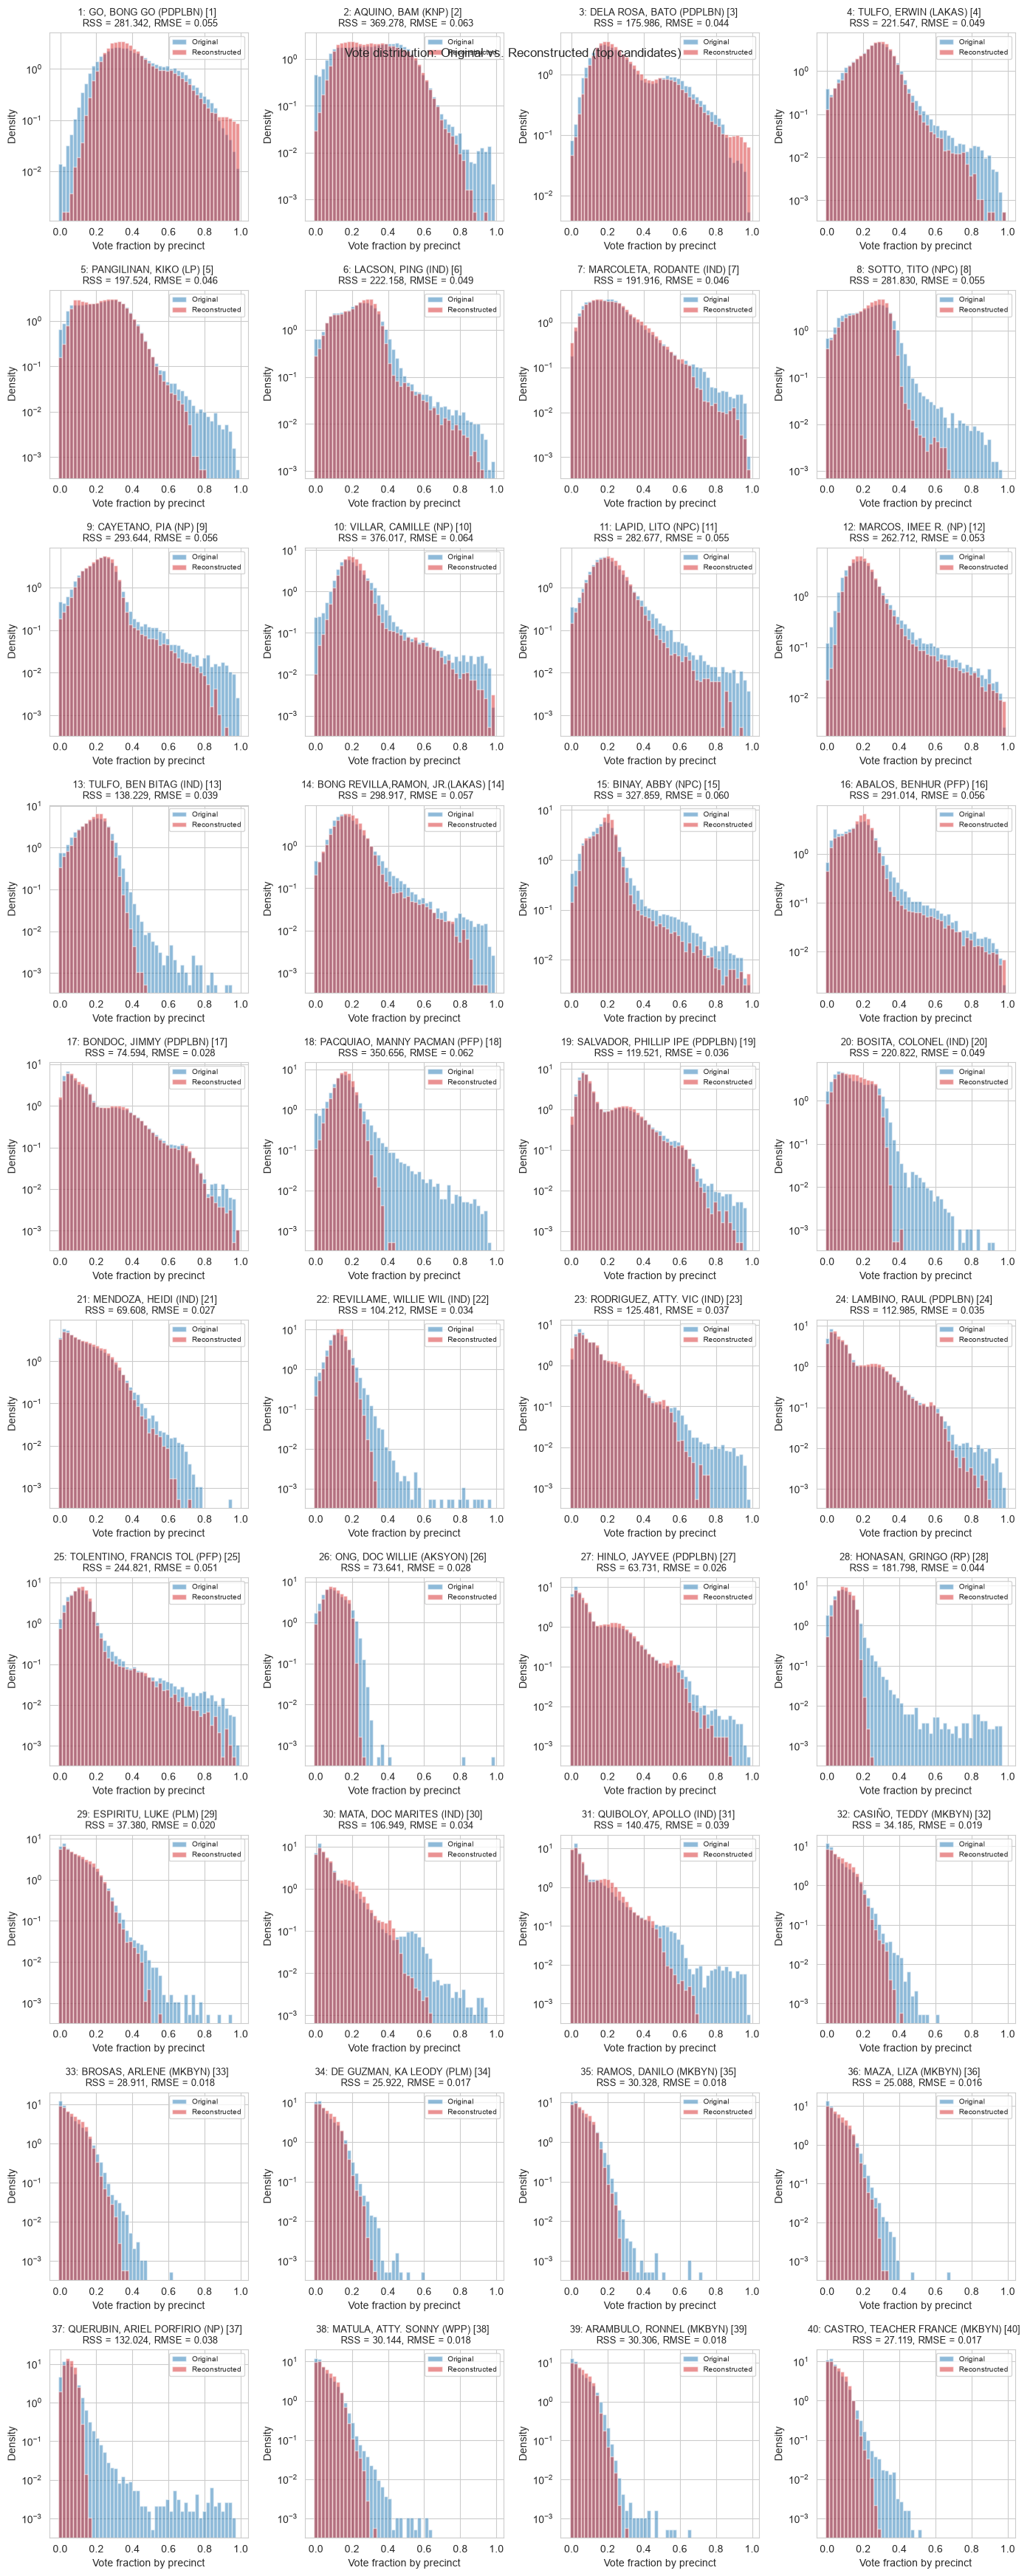

In [11]:
# Per-candidate reconstruction: original vs. reconstructed distributions
n_show_recon = min(40, L)
ncols_r = 4
nrows_r = int(np.ceil(n_show_recon / ncols_r))

xmin = np.floor(np.nanmin(Y))
xmax = np.ceil(np.nanmax(Y))
bins_r = np.linspace(xmin, xmax, 50)

fig, axs = plt.subplots(nrows_r, ncols_r, figsize=(ncols_r * 3.5, nrows_r * 3.5))
axs_flat = axs.flatten()

for i in range(n_show_recon):
    ax = axs_flat[i]

    rss_by_candidate = np.sum((Y[i, :] - Y_rec[i, :]) ** 2)
    rmse_by_candidate = np.sqrt(np.mean((Y[i, :] - Y_rec[i, :]) ** 2))

    hist, edges = np.histogram(Y[i, :], bins=bins_r, density=True)
    hist_rec, edges_rec = np.histogram(Y_rec[i, :], bins=bins_r, density=True)

    ax.bar(edges[:-1], hist, width=np.diff(edges), color='C0', alpha=0.5, label='Original')
    ax.bar(edges_rec[:-1], hist_rec, width=np.diff(edges_rec), color='C3', alpha=0.5, label='Reconstructed')
    ax.set_title(f'{i+1}: {pre.candidate_labels[i]} \n RSS = {rss_by_candidate:.3f}, RMSE = {rmse_by_candidate:.3f}', fontsize=9)
    ax.set_yscale('log')
    ax.legend(fontsize=7)
    ax.set_ylabel('Density')
    ax.set_xlabel('Vote fraction by precinct')

for k in range(n_show_recon, len(axs_flat)):
    axs_flat[k].set_visible(False)


fig.tight_layout()
fig.suptitle('Vote distribution: Original vs. Reconstructed (top candidates)', fontsize=12)

plt.show()

In [17]:
hist

array([1.08991318e+01, 1.21028469e+01, 8.48799291e+00, 5.88135630e+00,
       4.21088369e+00, 3.09299685e+00, 1.93749392e+00, 1.03152876e+00,
       5.69539503e-01, 3.18942122e-01, 1.67947928e-01, 1.00132992e-01,
       5.45698314e-02, 3.81459016e-02, 3.39074681e-02, 1.74835382e-02,
       1.64239298e-02, 1.32451047e-02, 1.53643215e-02, 3.17882513e-03,
       2.64902094e-03, 1.58941257e-03, 1.58941257e-03, 5.29804189e-04,
       0.00000000e+00, 5.29804189e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00])

In [18]:
hist_rec

array([1.01893945e+01, 1.03061800e+01, 7.95786011e+00, 6.82893397e+00,
       5.50755855e+00, 4.24375343e+00, 2.39382784e+00, 1.00007833e+00,
       3.43228636e-01, 1.25009791e-01, 5.70220099e-02, 3.34456019e-02,
       1.09657711e-02, 2.19315423e-03, 5.48288556e-04, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00])

In [19]:
entropy(hist + 1e-9, hist_rec+ 1e-9)

np.float64(0.04607813309708862)

/var/folders/k7/yq0x0lnn2ns__6748g658mxm0000gn/T/ipykernel_39361/3872492850.py:14: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".:" (-> linestyle=':'). The keyword argument will take precedence.
  axs[1].plot(rss_by_candidate, ".:", linestyle='None')
/var/folders/k7/yq0x0lnn2ns__6748g658mxm0000gn/T/ipykernel_39361/3872492850.py:15: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".:" (-> linestyle=':'). The keyword argument will take precedence.
  axs[2].plot(rmse_by_candidate, ".:", linestyle='None')
/var/folders/k7/yq0x0lnn2ns__6748g658mxm0000gn/T/ipykernel_39361/3872492850.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".:" (-> linestyle=':'). The keyword argument will take precedence.
  axs[3].plot(kldiv_by_candidate, ".:", linestyle='None')
/var/folders/k7/yq0x0lnn2ns__6748g658mxm0000gn/T/ipykernel_39361/38724928

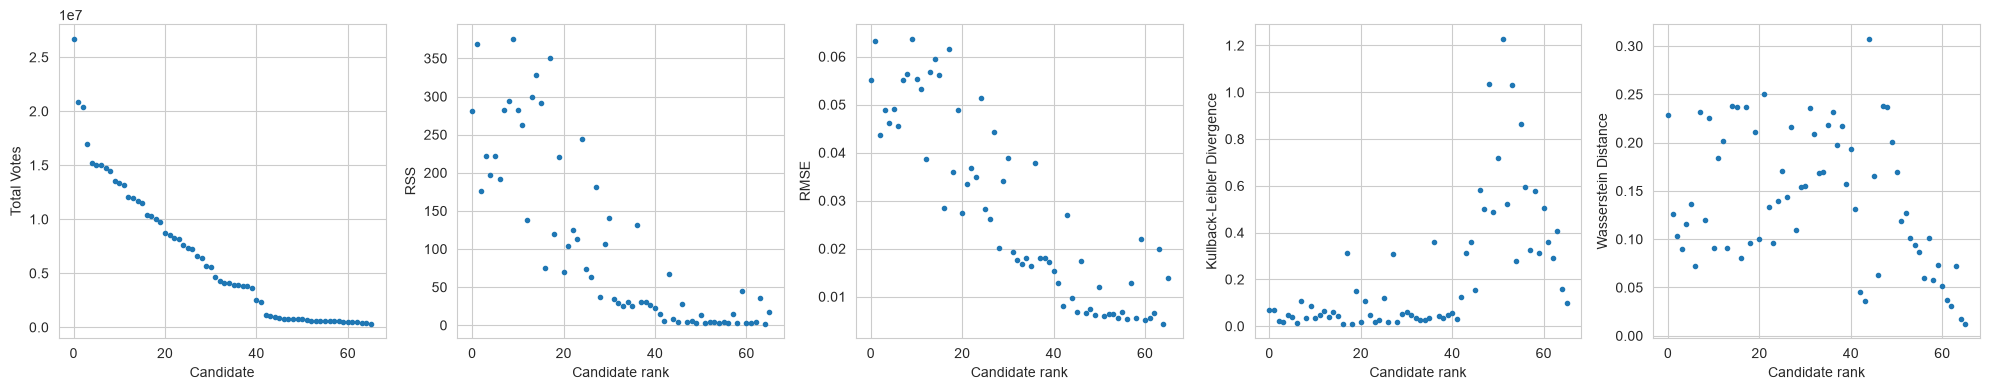

In [24]:
rss_by_candidate = np.sum((Y - Y_rec) ** 2, axis=1)
rmse_by_candidate = np.sqrt(np.mean((Y - Y_rec) ** 2, axis=1))

kldiv_by_candidate = np.zeros(L)
wass_by_candidate = np.zeros(L)
for i in range(L):
    hist, edges = np.histogram(Y[i, :], bins=bins_r, density=True)
    hist_rec, edges_rec = np.histogram(Y_rec[i, :], bins=bins_r, density=True)
    kldiv_by_candidate[i] = entropy(hist + 1e-9, hist_rec + 1e-9)
    wass_by_candidate[i] = wasserstein_distance(hist, hist_rec)

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
axs[0].plot(Y_raw.sum(axis=1), ".")
axs[1].plot(rss_by_candidate, ".:", linestyle='None')
axs[2].plot(rmse_by_candidate, ".:", linestyle='None')
axs[3].plot(kldiv_by_candidate, ".:", linestyle='None')
axs[4].plot(wass_by_candidate, ".:", linestyle='None')

axs[0].set_ylabel('Total Votes')
axs[0].set_xlabel('Candidate')
axs[1].set_ylabel('RSS')
axs[1].set_xlabel('Candidate rank')
axs[2].set_ylabel('RMSE')
axs[2].set_xlabel('Candidate rank')
axs[3].set_ylabel('Kullback-Leibler Divergence')
axs[3].set_xlabel('Candidate rank')
axs[4].set_ylabel('Wasserstein Distance')
axs[4].set_xlabel('Candidate rank')
fig.tight_layout()

In [23]:
pre.candidate_labels

['GO, BONG GO (PDPLBN) [1]',
 'AQUINO, BAM (KNP) [2]',
 'DELA ROSA, BATO (PDPLBN) [3]',
 'TULFO, ERWIN (LAKAS) [4]',
 'PANGILINAN, KIKO (LP) [5]',
 'LACSON, PING (IND) [6]',
 'MARCOLETA, RODANTE (IND) [7]',
 'SOTTO, TITO (NPC) [8]',
 'CAYETANO, PIA (NP) [9]',
 'VILLAR, CAMILLE (NP) [10]',
 'LAPID, LITO (NPC) [11]',
 'MARCOS, IMEE R. (NP) [12]',
 'TULFO, BEN BITAG (IND) [13]',
 'BONG REVILLA,RAMON, JR.(LAKAS) [14]',
 'BINAY, ABBY (NPC) [15]',
 'ABALOS, BENHUR (PFP) [16]',
 'BONDOC, JIMMY (PDPLBN) [17]',
 'PACQUIAO, MANNY PACMAN (PFP) [18]',
 'SALVADOR, PHILLIP IPE (PDPLBN) [19]',
 'BOSITA, COLONEL (IND) [20]',
 'MENDOZA, HEIDI (IND) [21]',
 'REVILLAME, WILLIE WIL (IND) [22]',
 'RODRIGUEZ, ATTY. VIC (IND) [23]',
 'LAMBINO, RAUL (PDPLBN) [24]',
 'TOLENTINO, FRANCIS TOL (PFP) [25]',
 'ONG, DOC WILLIE (AKSYON) [26]',
 'HINLO, JAYVEE (PDPLBN) [27]',
 'HONASAN, GRINGO (RP) [28]',
 'ESPIRITU, LUKE (PLM) [29]',
 'MATA, DOC MARITES (IND) [30]',
 'QUIBOLOY, APOLLO (IND) [31]',
 'CASIÑO, TEDDY (MK

## Save for the app / plot notebooks

Writes `data/processed/{endmembers.csv, abundances.parquet, meta.json}` —
the same artifacts as `scripts/run_pipeline.py`.

In [ ]:
# from src.data.loading import save_processed

# meta = {
#     'preprocessing': pre.params,
#     'hysime_kf': int(kf),
#     'n_archetypes': int(n_archetypes),
#     'seed': config['unmixing'].getint('seed'),
#     'rmse': float(rmse),
#     'candidate_labels': pre.candidate_labels,
# }
# save_processed(pre, endm, abundances, meta, config)

PosixPath('/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/data/processed')